# Removing the depth signal from shallow water, without drawing a polygon

*Automating Lyzenga's depth-invariant index: superpixels and clustering supply the two
reference regions an analyst would normally draw by hand.*

Water attenuates light exponentially, and wavelength by wavelength: blue reaches ~20 m,
green ~15 m, red ~5 m. So the same coral at 2 m and at 8 m has two different spectra, and
separating substrate from depth is a precondition for classifying substrate at all.

Lyzenga's 1978 depth-invariant index does that separation, and it has outlived a lot of
more sophisticated methods for one reason: it needs no auxiliary data. Every parameter
comes from the image. Except that in practice two of them come from an analyst drawing
polygons, over deep water, and over uniform substrate at varying depth, and that step is
why published DII results are so hard to reproduce. Papers almost never say where the
polygons were. Automating those two polygons away is the whole content of this notebook.

The DII is not a water column *correction*: it does not
recover the substrate's true spectrum. It is a unitless index that removes the brightness
variation caused by submergence depth, trading spectral fidelity for a scene derived
normalisation that needs nothing but the image itself, generally speaking this can be tied back using some kind of bathymetric survey.

**The data.** `reef_clear.npy` is a ribbon reef on the outer Great Barrier Reef, clipped
from a Sentinel-2 L1C scene over tile 55LCD (2020-05-31): 656×333 pixels at 10 m, all 13
MSI bands as ESA delivers them (DN = reflectance × 10 000). We take a cloud free section, so that the depth machinery can be seen working on its own. On more complex scenes some masking is likely required, the [companion notebook](02_cloud_and_land_masking.ipynb) does
that, you can pass the resulting water mask to `slic` below via `mask=`; everything
downstream is unchanged.

656x333 pixels, 13 bands


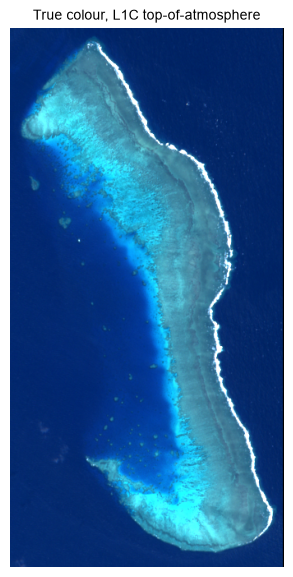

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from skimage.filters import threshold_otsu
from skimage.segmentation import mark_boundaries, slic
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

# Sentinel-2 MSI band order in the cube: B01 B02 B03 B04 B05 B06 B07 B08 B8A B09 B10 B11 B12
BLUE, GREEN, RED = 1, 2, 3

reef = np.load("../data/reef_clear.npy").astype(np.float32) / 10000.0
print(f"{reef.shape[0]}x{reef.shape[1]} pixels, {reef.shape[2]} bands")


def stretch(img, low=2, high=98):
    """Percentile stretch to [0, 1] for display only."""
    lo, hi = np.nanpercentile(img, [low, high])
    return np.clip((img - lo) / (hi - lo), 0, 1)


rgb = stretch(reef[:, :, [RED, GREEN, BLUE]])
plt.figure(figsize=(4.5, 7))
plt.imshow(rgb)
plt.title("True colour, L1C top-of-atmosphere")
plt.axis("off")
plt.show()

The depth signal is the thing to notice in that image. Brightness falls off continuously
from the reef flat, through the slope, out into open water and that gradient is water depth. It is what the index tries to remove.

## Lyzenga's depth-invariant index

Beer's law says radiance decays as $I(z) = I_0 e^{-kz}$ with a wavelength-specific $k$.
Take logs and the exponential becomes linear, which is the whole basis of the method. For
a pair of bands $i, j$:

$$\mathrm{DII}(i,j) = \ln(L_i - L_{s,i}) - \frac{k_i}{k_j}\ln(L_j - L_{s,j})$$

Two quantities have to come from somewhere: $L_s$, the deep-water radiance where no light
reaches bottom, and $k_i/k_j$, the ratio of attenuation coefficients. The first needs a
deep water region; the second needs a region of uniform substrate at varying depth. Both
are found below by segmentation and clustering.

## Superpixel aggregation and sub-pixel mixing

At 10 m every pixel over a reef mixes water column, substrate and surface, and that mixing
is enough to smear reef and water into a single blob in PC space. Averaging over spatially coherent segments cancels the mixing and the populations come apart. SLIC or any other super pixel help because they adhere to boundaries rather than a fixed grid which would contain both.

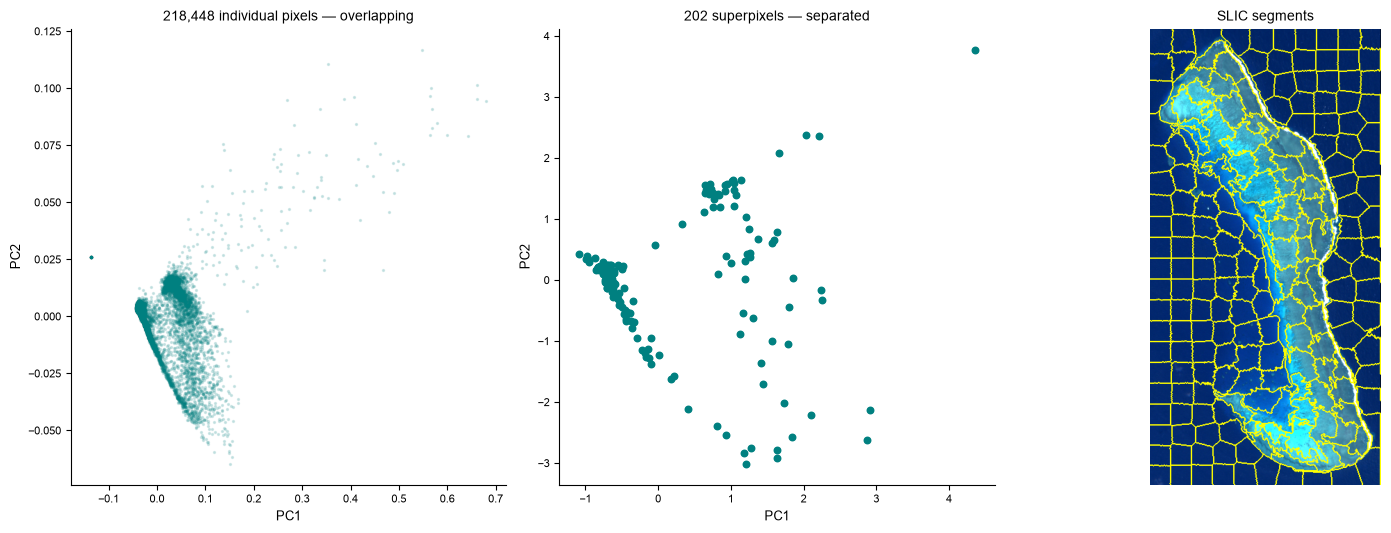

In [6]:
segments = slic(rgb, n_segments=250, compactness=10, start_label=1)
ids = np.unique(segments)
segment_means = np.stack([reef[segments == i][:, [BLUE, GREEN, RED]].mean(axis=0)
                          for i in ids])

pixel_pcs = PCA(n_components=2).fit_transform(
    reef[:, :, [BLUE, GREEN, RED]].reshape(-1, 3))
# Standardised so that the clustering radius below is in units of spread, not reflectance.
segment_pcs = StandardScaler().fit_transform(PCA(n_components=2).fit_transform(segment_means))

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
axes[0].scatter(pixel_pcs[::20, 0], pixel_pcs[::20, 1], s=2, alpha=0.15, color="teal")
axes[0].set(title=f"{len(pixel_pcs):,} individual pixels — overlapping",
            xlabel="PC1", ylabel="PC2")
axes[1].scatter(segment_pcs[:, 0], segment_pcs[:, 1], s=22, color="teal")
axes[1].set(title=f"{len(ids)} superpixels — separated", xlabel="PC1", ylabel="PC2")
axes[2].imshow(mark_boundaries(rgb, segments, color=(1, 1, 0)))
axes[2].set_title("SLIC segments")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Locating the deep-water reference

Now the first polygon draws itself. Cluster the superpixels and take the group with the
lowest PC1 as deep water — PC1 is brightness, and deep water is the darkest thing in a
marine scene. DBSCAN is used out of habit rather than necessity: once the populations
separate this cleanly, any sane clustering finds them, which the k-means cross-check
confirms rather than assumes — and the radius is equally uncritical: re-clustering
across a range of `eps` selects an almost identical deep-water region, as the sweep
printed below shows.

In [9]:
segment_labels = DBSCAN(eps=0.5, min_samples=10).fit_predict(segment_pcs)
cluster_pc1 = {c: segment_pcs[segment_labels == c, 0].mean()
               for c in np.unique(segment_labels) if c != -1}
deep_cluster = min(cluster_pc1, key=cluster_pc1.get)

label_map = np.full(segments.shape, -9)
for i, lab in zip(ids, segment_labels):
    label_map[segments == i] = lab
deep = label_map == deep_cluster
shallow = ~deep
print(f"{len(cluster_pc1)} clusters; deep water = cluster {deep_cluster}, "
      f"{deep.mean():.0%} of the scene")

2 clusters; deep water = cluster 0, 64% of the scene


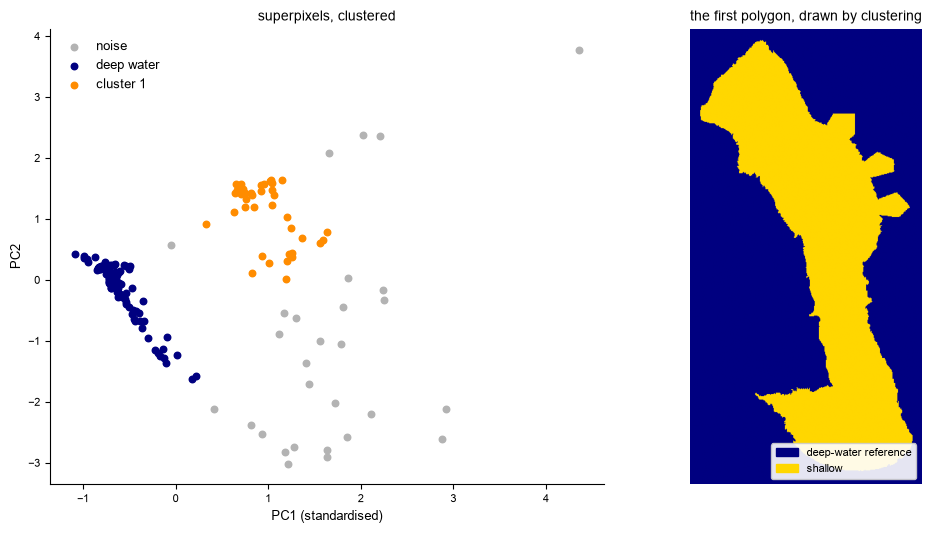

In [10]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 5.4))
for c in np.unique(segment_labels):
    m = segment_labels == c
    a.scatter(segment_pcs[m, 0], segment_pcs[m, 1], s=22,
              label="noise" if c == -1 else ("deep water" if c == deep_cluster else f"cluster {c}"),
              color="0.7" if c == -1 else ("navy" if c == deep_cluster else "darkorange"))
a.set(xlabel="PC1 (standardised)", ylabel="PC2", title="superpixels, clustered")
a.legend(frameon=False, fontsize=9)
b.imshow(np.where(deep, 0, 1), vmin=0, vmax=1,
         cmap=ListedColormap(["navy", "gold"]))
b.set_title("the first polygon, drawn by clustering")
b.legend(handles=[Patch(color="navy", label="deep-water reference"),
                  Patch(color="gold", label="shallow")],
         loc="lower right", frameon=True, framealpha=0.9)
b.axis("off")
plt.tight_layout()
plt.show()

The reference region traces the reef outline without anyone specifying the outline. That
is the whole of the first polygon problem, solved by the observation that deep water is
both dark and abundant.

## Estimating the attenuation ratio

$k_i/k_j$ is the slope of a cloud of points in log space in which *both* axes are noisy.
Lyzenga's formulation takes the principal axis of the covariance, which treats the two
bands symmetrically rather than assuming, as ordinary least squares does, that one of them
is exact:

$$\frac{k_i}{k_j} = a + \sqrt{a^2 + 1}, \qquad a = \frac{\sigma_{ii} - \sigma_{jj}}{2\sigma_{ij}}$$

The superpixels earn their keep a second time here, as the second polygon. A slope fitted
across the whole reef mixes coral, sand and rubble, so substrate differences masquerade as
depth. Fitting within each superpixel is spatially coherent, so roughly one substrate and
taking the **median** gives a slope that describes attenuation rather than substrate, and
the median matters: individual segments span a narrow depth range, so any one of them can
produce a wild estimate, and a global fit to this scene returns 45 for the blue/red pair.

In [11]:
def principal_axis_slope(xi, xj):
    a = (xi.var() - xj.var()) / (2 * np.cov(xi, xj)[0, 1])
    return a + np.sqrt(a * a + 1)


def index_stretch(band, mask, low=2, high=98):
    """Stretch driven only by pixels carrying a bottom signal.

    Half this scene sits on the deep-water floor. Percentiles taken over the whole
    image are dominated by that spike, which compresses the reef into a narrow band
    of the colour ramp — the difference between a washed-out image and a readable one.
    """
    lo, hi = np.percentile(band[mask], [low, high])
    return np.clip((band - lo) / (hi - lo), 0, 1)


def depth_invariant(i, j, min_pixels=80):
    """Lyzenga's index for one band pair, both parameters read off the image."""
    Ls_i, Ls_j = reef[deep][:, i].mean(), reef[deep][:, j].mean()

    # Only pixels brighter than the deep-water reference carry a bottom signal at all.
    usable = (reef[:, :, i] > Ls_i) & (reef[:, :, j] > Ls_j)
    log_i = np.log(np.where(usable, reef[:, :, i] - Ls_i, 1))
    log_j = np.log(np.where(usable, reef[:, :, j] - Ls_j, 1))

    slopes = []
    for s in np.unique(segments[shallow & usable]):
        m = (segments == s) & shallow & usable
        if m.sum() >= min_pixels and log_i[m].std() > 1e-3:
            slopes.append(principal_axis_slope(log_i[m], log_j[m]))
    ki_kj = float(np.median(slopes))

    index = np.where(usable, log_i - ki_kj * log_j, -np.inf)
    # Optically deep pixels have no bottom signal to recover; park them at the floor of
    # the usable population rather than dropping them, so the deep-water class survives
    # into the thresholding step below.
    floor = np.percentile(index[usable], 0.5)
    return np.maximum(index, floor), ki_kj, usable, len(slopes)


dii, k_bg, valid, n_used = depth_invariant(BLUE, GREEN)
print(f"blue/green attenuation ratio {k_bg:.2f}, median over {n_used} superpixels")
print(f"a bottom signal is recoverable for {valid.mean():.0%} of the scene")

blue/green attenuation ratio 1.62, median over 67 superpixels
a bottom signal is recoverable for 50% of the scene


## The transformed image

What the index does is remove a *gradient* and keep a *contrast*. In true colour,
brightness falls away continuously from the reef flat down the slope, that gradient is
depth. In the index it is gone, and what remains varies where the bottom itself changes.
The index is unitless: only differences within a scene are interpretable, and only for
pixels the transformation was valid for, because $L_s$ and $k_i/k_j$ are re-estimated
from every image. Quantifying how well the depth signal was removed would need
bathymetry or field spectra at known depths over known substrate.

A single band pair is not a sufficient description of the bottom, though. Each pair is
sensitive to a different slice of the depth–substrate space — blue/green reaches deepest,
green/red is confined to the shallows but discriminates substrate there. In the composite of all three, colour varies with substrate rather than with depth.

blue/green   attenuation ratio 1.62
blue/red     attenuation ratio 2.00
green/red    attenuation ratio 0.79


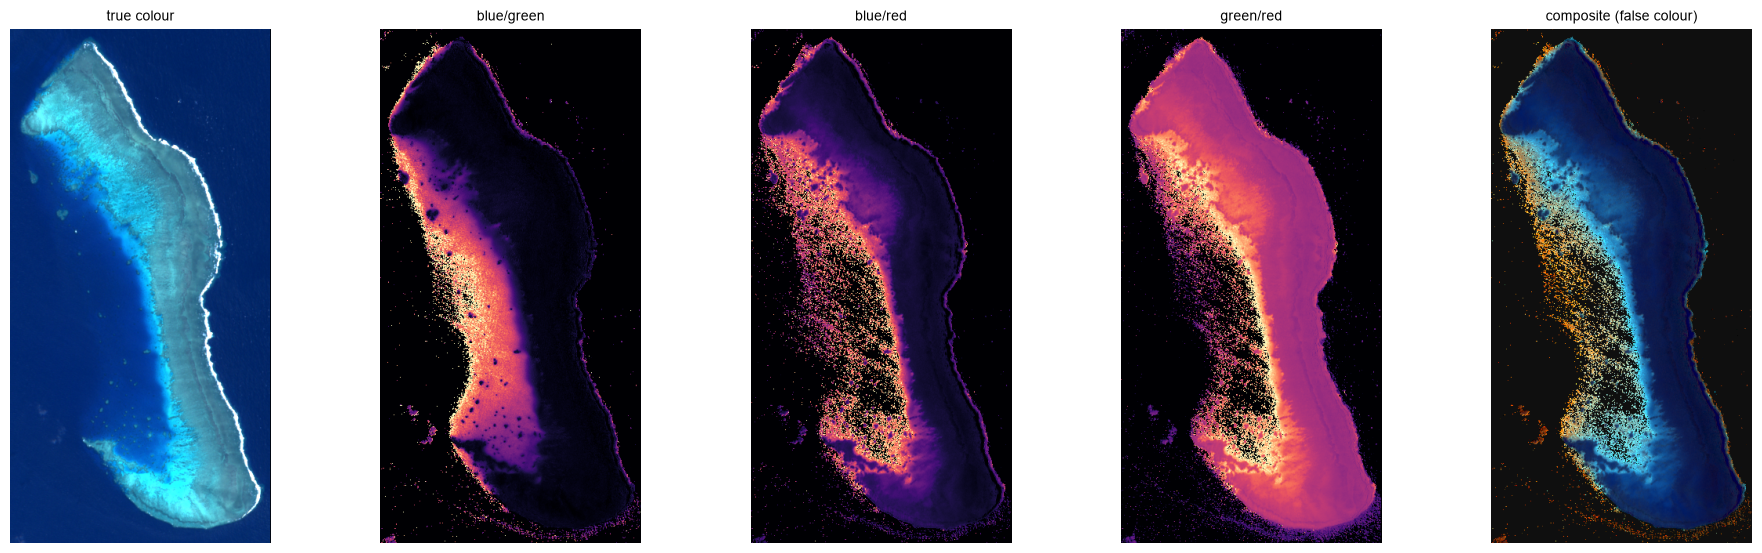

In [12]:
pairs = [(BLUE, GREEN), (BLUE, RED), (GREEN, RED)]
labels = ["blue/green", "blue/red", "green/red"]

stack, ratios, masks = [], [], []
for i, j in pairs:
    band, ratio, usable, _ = depth_invariant(i, j)
    stack.append(band)
    ratios.append(ratio)
    masks.append(usable)
stack = np.stack(stack, axis=-1)
bottom = np.logical_and.reduce(masks)   # all three pairs defined

for name, ratio in zip(labels, ratios):
    print(f"{name:<12} attenuation ratio {ratio:.2f}")


# Optically deep pixels are rendered black throughout: no bottom signal, nothing to show.
composite = np.stack([index_stretch(stack[:, :, c], bottom) for c in range(3)], axis=-1)
composite[~bottom] = 0.06

fig, axes = plt.subplots(1, 5, figsize=(19, 5.6))
axes[0].imshow(rgb); axes[0].set_title("true colour")
for ax, c, name in zip(axes[1:4], range(3), labels):
    ax.imshow(np.where(masks[c], index_stretch(stack[:, :, c], masks[c]), 0.0),
              cmap="magma", vmin=0, vmax=1)
    ax.set_title(name)
axes[4].imshow(composite); axes[4].set_title("composite (false colour)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The three pairs are visibly not redundant: blue/green picks out the western lagoon floor
that green/red cannot reach, and green/red resolves the reef flat that blue/green
flattens. This suggests that the signal along the western margin is real, not a processing artefact,
where $L - L_s$ approaches zero and the logarithm amplifies sensor signal/noise.


## Thresholding the composite

Otsu's method takes one channel, so the stack has to be reduced to one. Averaging the
pairs would weight them arbitrarily; the first principal component instead weights them
by the variation they agree on, the bottom signal they share. Its sign is arbitrary, so
it is oriented to run from deep to shallow using the clustering, not by eye. Then Otsu
picks the threshold maximising between-class variance. In practice there are a lot of ways to do this and this is not neccecarily the best one.


composite:        Otsu extracts 47% of the scene, 84% agreement with the shallow-water cluster
blue/green alone: Otsu extracts 14% of the scene, 51% agreement


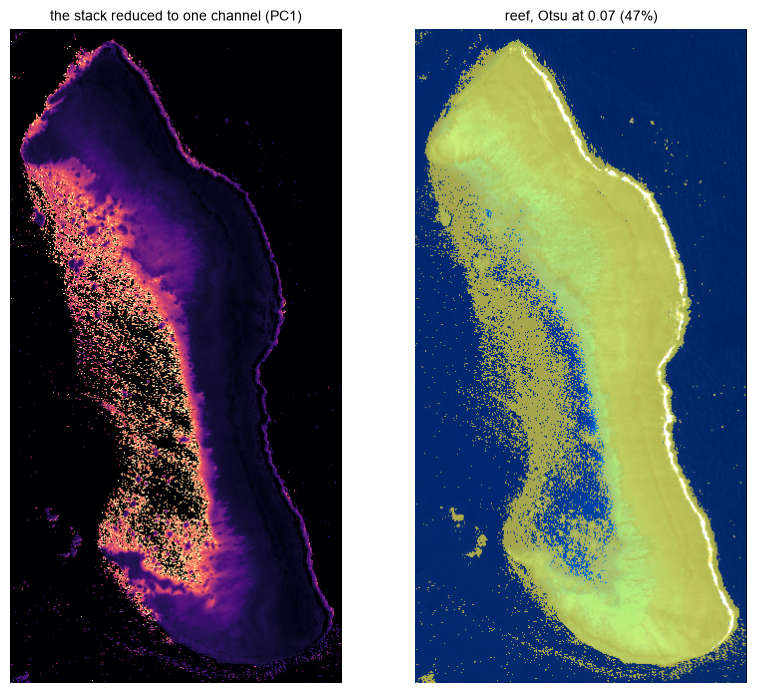

In [13]:
components = PCA(n_components=1).fit_transform(
    StandardScaler().fit_transform(stack.reshape(-1, len(pairs))))
brightness = components[:, 0].reshape(reef.shape[:2])
if brightness[shallow].mean() < brightness[deep].mean():
    brightness = -brightness          # orient: shallow high, deep low

threshold = threshold_otsu(brightness)
extracted = brightness > threshold

print(f"composite:        Otsu extracts {extracted.mean():.0%} of the scene, "
      f"{np.mean(extracted == shallow):.0%} agreement with the shallow-water cluster")

single = stack[:, :, 0] > threshold_otsu(stack[:, :, 0])
print(f"blue/green alone: Otsu extracts {single.mean():.0%} of the scene, "
      f"{np.mean(single == shallow):.0%} agreement")

fig, (a, b) = plt.subplots(1, 2, figsize=(8.5, 7))
a.imshow(np.where(bottom, index_stretch(brightness, bottom), 0.0),
         cmap="magma", vmin=0, vmax=1)
a.set_title("the stack reduced to one channel (PC1)")
overlay = rgb.copy()
overlay[extracted] = 0.35 * overlay[extracted] + 0.65 * np.array([1.0, 0.9, 0.2])
b.imshow(overlay)
b.set_title(f"reef, Otsu at {threshold:.2f} ({extracted.mean():.0%})")
for ax in (a, b):
    ax.axis("off")
plt.tight_layout()
plt.show()


## Limitations

**Optically deep water.** The index is undefined wherever a band falls below its
deep-water reference. Since those pixels have no
recoverable bottom signal, and saying so is better than extrapolating. It does mean the
usable area is much smaller than the scene.

**The reef crest.** The white line along the windward edge is breaking surf, not
substrate. It violates the assumption that what reaches the sensor came back through the
water column, so its index values are meaningless
even though the extraction happily includes it. Whitecaps are common on outer reefs and
nothing here handles them, though the residual trick at the end of the
[masking notebook](02_cloud_and_land_masking.ipynb) can pick out these pixels, or potentially there are suitable thresholds to pick from.

**Cloud shadow.** This scene has none, which is why it was chosen. On a scene that does,
shadowed water is darker than clear water, which is what deep water looks like to a
brightness-driven method, so shadow is pulled into the deep-water cluster, where it
biases $L_s$ and skews $k_i/k_j$ for the entire scene. That is the sharpest edge here, and
the reason to mask before you correct, in such situations where you need these pixels, fmask is probably a better preprocessing choice.

**Turbidity and homogeneity.** The separation exploited above needs clear water; suspended
sediment closes the gap between reef and water. And Lyzenga assumes uniform optical
properties across the scene, a river plume or a bloom violates that, though estimating
the parameters per superpixel localises the damage.

## Summary

Beer's law and Lyzenga's algebra are unchanged since 1978.
What is improved here is avoiding the manual selection of same deep water areas. Both reference regions — deep water for
$L_s$, uniform substrate for $k_i/k_j$, are found by segmentation and clustering, both
deterministic, so identical inputs give identical outputs and a result can be reproduced
from the image alone. This should in theory make this more deterministic if seeds etc are set and it is possible to fully automate.

---
**See also:** [finding the usable images](01_pca_image_selection.ipynb) in an archive, and
[masking cloud and land](02_cloud_and_land_masking.ipynb), which you need first on any
scene less obliging than this one.